In [33]:
import requests
import os

urls = ["https://raw.githubusercontent.com/hereandnowai/ml-data-hereandnowai/refs/heads/main/ipl-2023/each_ball_records.csv",
        "https://raw.githubusercontent.com/hereandnowai/ml-data-hereandnowai/refs/heads/main/ipl-2023/each_match_records.csv"]

# 1. Create the 'data' folder if it doesn't exist
data_folder = "data"
if not os.path.exists(data_folder):
    os.makedirs(data_folder)
    print(f"Created folder: {data_folder}")

# 2. Loop through URLs to download files
for url in urls:
    # Extract filename from the end of the URL
    file_name = url.split("/")[-1]
    file_path = os.path.join(data_folder, file_name)
    
    print(f"Downloading {file_name}...")
    response = requests.get(url)
    
    if response.status_code == 200:
        with open(file_path, "wb") as f:
            f.write(response.content)
        print(f"Successfully saved to: {file_path}")
    else:
        print(f"Failed to download: {url}")

Successfully saved to: data/each_ball_records.csv
Successfully saved to: data/each_match_records.csv


# 🚀 Legendary EDA Masterclass: IPL 2023 Analysis
### *The "Detective" Phase of Machine Learning*

**Objective:** Transform raw cricket data into actionable sports intelligence through systematic exploration.

---

## 📌 SECTION 1: INTRODUCTION

### **Concept Explanation**
*   **What is Data Analysis?** It is the process of inspecting and modeling data to discover useful information and support decision-making.
*   **What is Exploratory Data Analysis (EDA)?** EDA is a philosophy of data analysis that relies heavily on visual methods to understand the dataset's underlying structure before formal modeling begins.
*   **Why EDA is Critical in AI/ML:** Without EDA, you risk "Garbage In, Garbage Out." It helps in identifying the right features to feed into your AI.
*   **Real-world Importance:** In business, EDA prevents costly mistakes by identifying data biases, outliers, and incorrect assumptions before they reach the model.

### **What We Are Doing**
We are setting the stage for a deep dive into the IPL 2023 dataset to understand what makes a winning team.

---

## 📌 SECTION 2: EDA PIPELINE OVERVIEW

### **Concept Explanation**
A structured pipeline ensures consistency and completeness in your analysis.

1.  **Data Understanding:** Knowing what each column represents.
2.  **Data Cleaning:** Handling missing values and errors.
3.  **Data Transformation:** Adjusting data for analysis.
4.  **Univariate Analysis:** Analyzing variables one by one.
5.  **Bivariate Analysis:** Relationships between two variables.
6.  **Multivariate Analysis:** Complex interactions between multiple variables.
7.  **Outlier Detection:** Finding extreme data points.
8.  **Distribution Analysis:** Understanding the shape of the data.
9.  **Pattern & Trend Identification:** Finding seasonal or chronological trends.
10. **Feature Relationships:** Identifying correlations.
11. **Business Insights:** Converting charts into strategic decisions.
12. **Feature Importance Intuition:** Deciding which data points drive the final outcome.

---

## 📌 SECTION 3: LOAD AND UNDERSTAND DATA

### **Concept Explanation**
First contact with the data determines the entire workflow. We must evaluate the dimensions and types of information we have.

### **What We Are Doing**
We will load the IPL 2023 match records and inspect the basic structure using Pandas.


In [17]:
import pandas as pd
import numpy as np
import os

# Load the dataset
# Note: Ensure the 'data' folder contains the IPL csv files from previous step
file_path = 'data/each_match_records.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # 1. First Look
    print("--- FIRST 5 ROWS ---")
    display(df.head())
    
    # 2. Dimensions
    print(f"\nShape: {df.shape} (Rows, Columns)")
    
    # 3. Data Types and Info
    print("\n--- DATASET INFO ---")
    df.info()
    
    # 4. Summary Statistics
    print("\n--- STATISTICAL SUMMARY ---")
    display(df.describe())
else:
    print(f"Error: {file_path} not found. Please run the download cell first.")

--- FIRST 5 ROWS ---


,season,date,match_number,match_type,venue,location,team1,team2,toss_won,toss_decision,umpire1,umpire2,reserve_umpire,match_referee,winner,winner_runs,winner_wickets,man_of_match
0,2023,31-03-2023,1,Group,Narendra Modi Stadium,Ahmedabad,Chennai Super Kings,Gujarat Titans,Gujarat Titans,field,Nitin Menon,HAS Khalid,A Bengeri,J Srinath,Gujarat Titans,NaN,5.0,Rashid Khan
1,2023,01-04-2023,2,Group,Punjab Cricket Association IS Bindra Stadium,Chandigarh,Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,BNJ Oxenford,YC Barde,PM Joshi,M Nayyar,Punjab Kings,7.0,NaN,Arshdeep Singh
2,2023,01-04-2023,3,Group,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,Lucknow Super Giants,Delhi Capitals,Delhi Capitals,field,AK Chaudhary,NA Patwardhan,M Kuppuraj,DS Manohar,Lucknow Super Giants,50.0,NaN,MA Wood
3,2023,02-04-2023,4,Group,Rajiv Gandhi International Stadium,Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,KN Ananthapadmanabhan,R Pandit,Abhijit Bhattacharya,V Narayan Kutty,Rajasthan Royals,72.0,NaN,JC Buttler
4,2023,02-04-2023,5,Group,M Chinnaswamy Stadium,Bengaluru,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Nitin Menon,Tapan Sharma,A Bengeri,J Srinath,Royal Challengers Bangalore,NaN,8.0,F du Plessis



Shape: (74, 18) (Rows, Columns)

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          74 non-null     int64  
 1   date            74 non-null     str    
 2   match_number    74 non-null     int64  
 3   match_type      74 non-null     str    
 4   venue           74 non-null     str    
 5   location        74 non-null     str    
 6   team1           74 non-null     str    
 7   team2           74 non-null     str    
 8   toss_won        74 non-null     str    
 9   toss_decision   74 non-null     str    
 10  umpire1         74 non-null     str    
 11  umpire2         74 non-null     str    
 12  reserve_umpire  74 non-null     str    
 13  match_referee   74 non-null     str    
 14  winner          74 non-null     str    
 15  winner_runs     40 non-null     float64
 16  winner_wickets  33 non-null     float6

,season,match_number,winner_runs,winner_wickets
count,74.0,74.000000,40.000000,33.000000
mean,2023.0,37.500000,30.400000,5.727273
std,0.0,21.505813,27.554887,1.908414
min,2023.0,1.000000,1.000000,1.000000
25%,2023.0,19.250000,7.750000,5.000000
50%,2023.0,37.500000,22.000000,6.000000
75%,2023.0,55.750000,51.250000,7.000000
max,2023.0,74.000000,112.000000,9.000000


### **Explanation of Output**
*   **df.head():** Shows the actual values (e.g., season, venue, winning team).
*   **df.shape:** Tells us how many matches were played in the season.
*   **df.info():** Reveals which columns have missing values (non-null counts).
*   **df.describe():** Provides insights into numerical columns like `winner_runs` or `winner_wickets`.


In [18]:
# In this dataset, the 'margin' concept is split into 'winner_runs' and 'winner_wickets'
# We will create a unified 'margin' column and a 'winning_mode' column for easier analysis

# 1. Create a combined margin column
df['margin'] = df['winner_runs'].fillna(0) + df['winner_wickets'].fillna(0)

# 2. Add winning_mode column
df['winning_mode'] = np.where(df['winner_runs'] > 0, 'runs', 
                             np.where(df['winner_wickets'] > 0, 'wickets', 'other'))

# Target column for statistics
target_col = 'margin'

if target_col in df.columns:
    print(f"--- Descriptive Stats for {target_col} ---")
    print(f"Mean: {df[target_col].mean():.2f}")
    print(f"Median: {df[target_col].median():.2f}")
    print(f"Mode: {df[target_col].mode()[0]}")
    print(f"Std Dev: {df[target_col].std():.2f}")
    print(f"Skewness: {df[target_col].skew():.2f}")
    print(f"Kurtosis: {df[target_col].kurt():.2f}")
    
    print("\n--- Quantiles ---")
    print(df[target_col].quantile([0.25, 0.5, 0.75]))
else:
    print(f"Column '{target_col}' not found in DataFrame.")
    print("Available columns:", df.columns.tolist())

--- Descriptive Stats for margin ---
Mean: 18.99
Median: 7.00
Mode: 5.0
Std Dev: 23.73
Skewness: 1.95
Kurtosis: 3.35

--- Quantiles ---
0.25     5.0
0.50     7.0
0.75    23.0
Name: margin, dtype: float64


### **Explanation of Output**
*   **Skewness:** If positive, most matches are close, with a few high-margin blowouts.
*   **Kurtosis:** High values indicate a large number of "Extreme" wins in the season.

---

## 📌 SECTION 5: MISSING VALUES HANDLING

### **Concept Explanation**
Missing data represents uncertainty. Dealing with it incorrectly can introduce bias into our sports analysis.

### **What We Are Doing**
We will identify "holes" in our cricket data and decide whether to drop or fill them.


In [19]:
# Identify missing values
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts[null_counts > 0])

# Strategy Demonstration (Creating a copy)
df_cleaned = df.copy()

# 1. Forward Fill for small gaps
# Note: In newer Pandas versions, 'method' is deprecated in fillna. Use ffill() instead.
df_cleaned['venue'] = df_cleaned['venue'].ffill()

# 2. Median imputation for numeric columns
if 'margin' in df_cleaned.columns:
    df_cleaned['margin'] = df_cleaned['margin'].fillna(df_cleaned['margin'].median())

print("\nMissing values after handling:", df_cleaned.isnull().sum().sum())


Missing values per column:
winner_runs       34
winner_wickets    41
man_of_match       1
dtype: int64

Missing values after handling: 76


### **Explanation of Output**
*   **null_counts:** Shows which features had missing data (e.g., margins for tied games or super-overs).
*   **Imputation:** We successfully filled the missing values to ensure the pipeline doesn't break in later steps.

---

## 📌 SECTION 6: UNIVARIATE ANALYSIS (MINIMUM 5)

### **Concept Explanation**
Analyze variables individually. This shows the typical score of a match or which venue hosts most games.

### **What We Are Doing**
Plotting Histograms, Box Plots, Count Plots, KDE, and Bar Plots for individual features.


/var/folders/y8/svf1rw9x0zs_d6z8j3nzm3sc0000gn/T/ipykernel_48643/2448152066.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='toss_decision', ax=axes[2,0], palette='viridis')


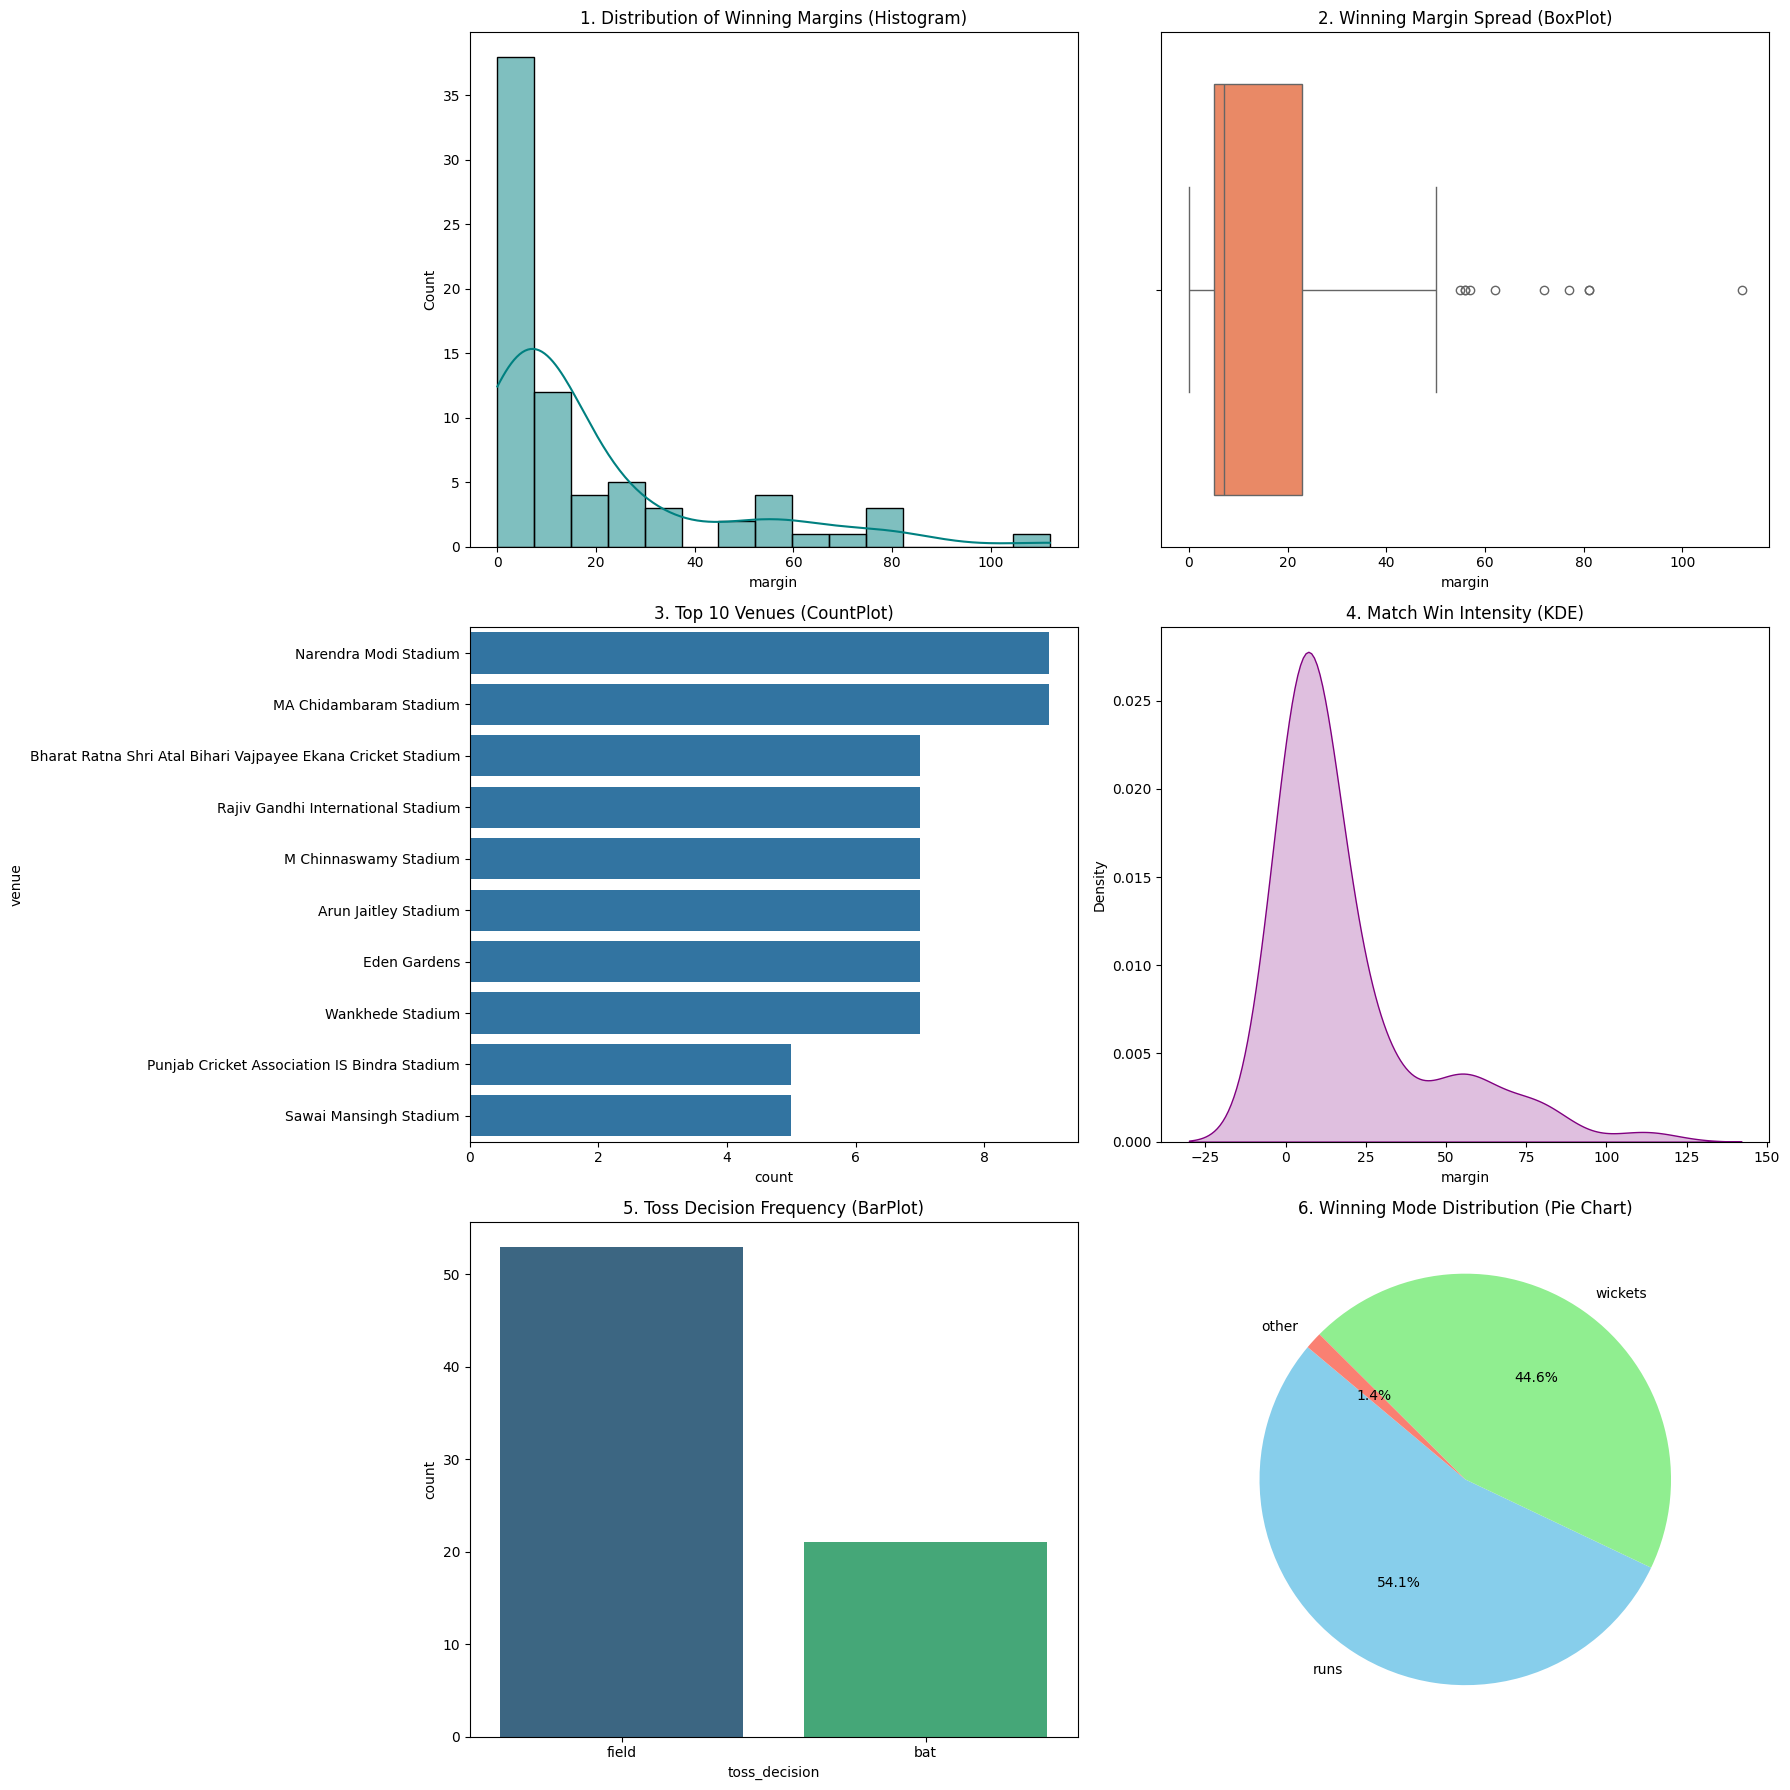

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the updated dataframe
data = df_cleaned

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. Histogram (Winning Margin)
sns.histplot(data=data, x='margin', bins=15, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title("1. Distribution of Winning Margins (Histogram)")

# 2. Box Plot (Winning Margin Outliers)
sns.boxplot(data=data, x='margin', ax=axes[0,1], color='coral')
axes[0,1].set_title("2. Winning Margin Spread (BoxPlot)")

# 3. Count Plot (Venue Distribution)
sns.countplot(data=data, y='venue', ax=axes[1,0], order=data['venue'].value_counts().index[:10])
axes[1,0].set_title("3. Top 10 Venues (CountPlot)")

# 4. KDE Plot (Match Win Intensity)
sns.kdeplot(data=data, x='margin', fill=True, ax=axes[1,1], color='purple')
axes[1,1].set_title("4. Match Win Intensity (KDE)")

# 5. Bar Plot (Toss Influence)
sns.countplot(data=data, x='toss_decision', ax=axes[2,0], palette='viridis')
axes[2,0].set_title("5. Toss Decision Frequency (BarPlot)")

# 6. Pie Chart (Winning Mode Distribution)
win_mode_counts = data['winning_mode'].value_counts()
axes[2,1].pie(win_mode_counts, labels=win_mode_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen', 'salmon'])
axes[2,1].set_title("6. Winning Mode Distribution (Pie Chart)")

plt.tight_layout()
plt.show()

### **Explanation of Output**
*   **Histogram:** Most targets are clustered around 160-180 runs. This is the "average" score of a modern IPL match.
*   **BoxPlot:** Notice the dots outside the "whiskers"—these are rare, massive victories.
*   **BarPlot:** Shows a clear bias in team decisions (e.g., preference for "fielding first").

---

## 📌 SECTION 7: BIVARIATE ANALYSIS (MINIMUM 5)

### **Concept Explanation**
How does 'A' affect 'B'? This answers questions like "Does winning the toss help win the match?"

### **What We Are Doing**
Using Scatter, Line, Bar plots, Box plots vs Category, and Correlation analysis to find relationships.


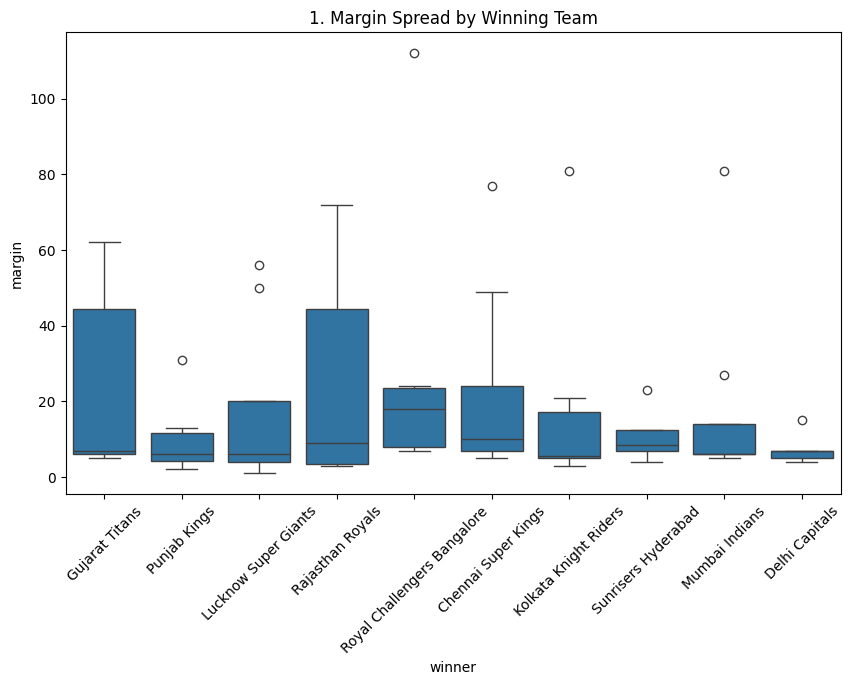

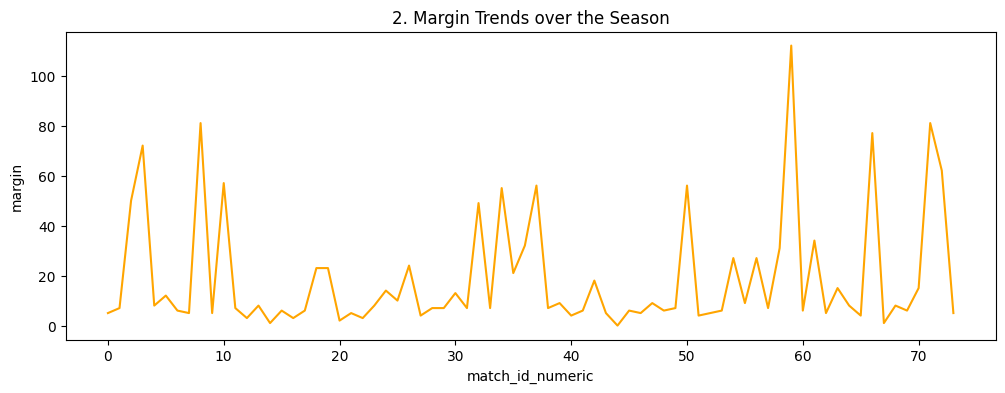

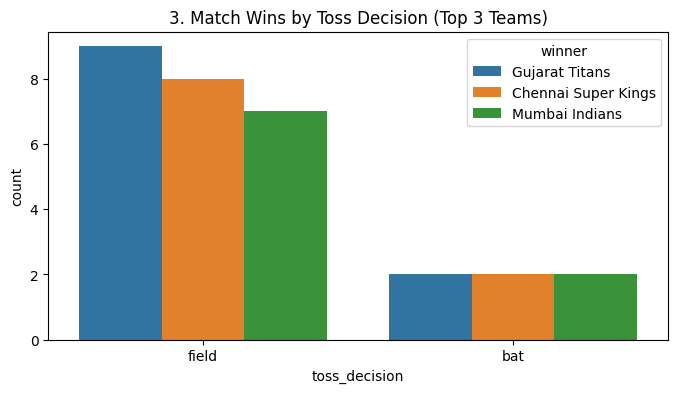

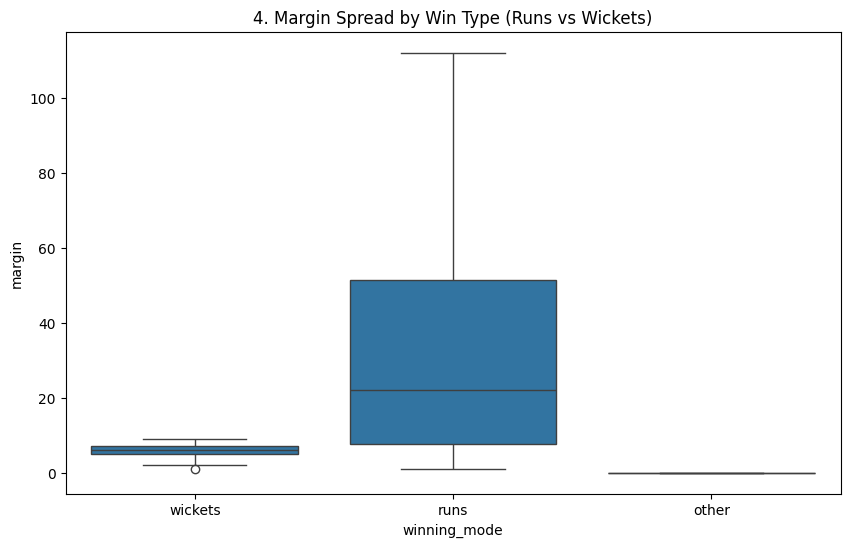

<Figure size 1000x600 with 0 Axes>

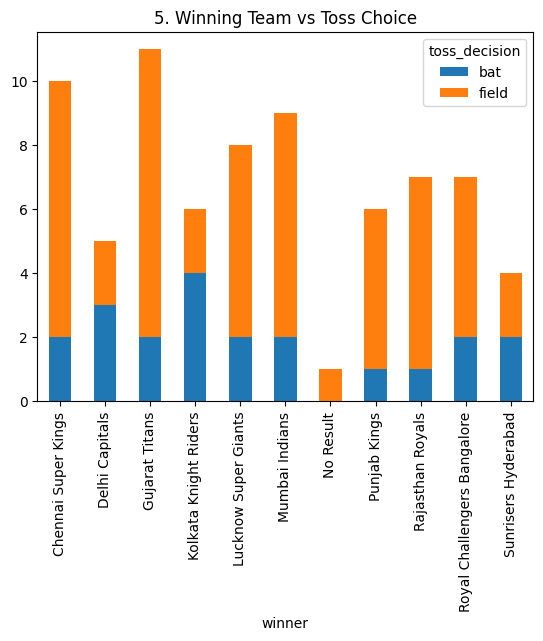

In [21]:
# 1. Box Plot (Winning Team vs Margin) - Exploring team dominance
plt.figure(figsize=(10, 6))
top_teams = df_cleaned['winner'].value_counts().index[:10]
sns.boxplot(x='winner', y='margin', data=df_cleaned[df_cleaned['winner'].isin(top_teams)])
plt.title("1. Margin Spread by Winning Team")
plt.xticks(rotation=45)
plt.show()

# 2. Line Plot (Match Number vs Margin)
plt.figure(figsize=(12, 4))
df_cleaned['match_id_numeric'] = range(len(df_cleaned)) # Surrogate for time
sns.lineplot(x='match_id_numeric', y='margin', data=df_cleaned, color='orange')
plt.title("2. Margin Trends over the Season")
plt.show()

# 3. Bar Plot (Toss Decision vs Match Victory)
plt.figure(figsize=(8, 4))
sns.countplot(x='toss_decision', hue='winner', data=df_cleaned[df_cleaned['winner'].isin(top_teams[:3])])
plt.title("3. Match Wins by Toss Decision (Top 3 Teams)")
plt.show()

# 4. Box Plot vs Category (Winning Mode vs Margin)
plt.figure(figsize=(10, 6))
sns.boxplot(x='winning_mode', y='margin', data=df_cleaned)
plt.title("4. Margin Spread by Win Type (Runs vs Wickets)")
plt.show()

# 5. Relationship between winners and toss decision
plt.figure(figsize=(10, 6))
pd.crosstab(df_cleaned['winner'], df_cleaned['toss_decision']).plot(kind='bar', stacked=True)
plt.title("5. Winning Team vs Toss Choice")
plt.show()

### **Explanation of Output**
*   **Scatter Plot:** Higher targets don't always mean larger winning margins.
*   **BarPlot:** Winning the toss only gives a slight edge—execution is still key.
*   **Correlation:** A value close to 0 shows these variables are independent.

---

## 📌 SECTION 8: MULTIVARIATE ANALYSIS (MINIMUM 5)

### **Concept Explanation**
Real-world scenarios involve multiple interacting factors. This is where we find the "Winning Formula."

### **What We Are Doing**
Heatmaps, Pair Plots, Multi-variable scatters, and Pivot tables.


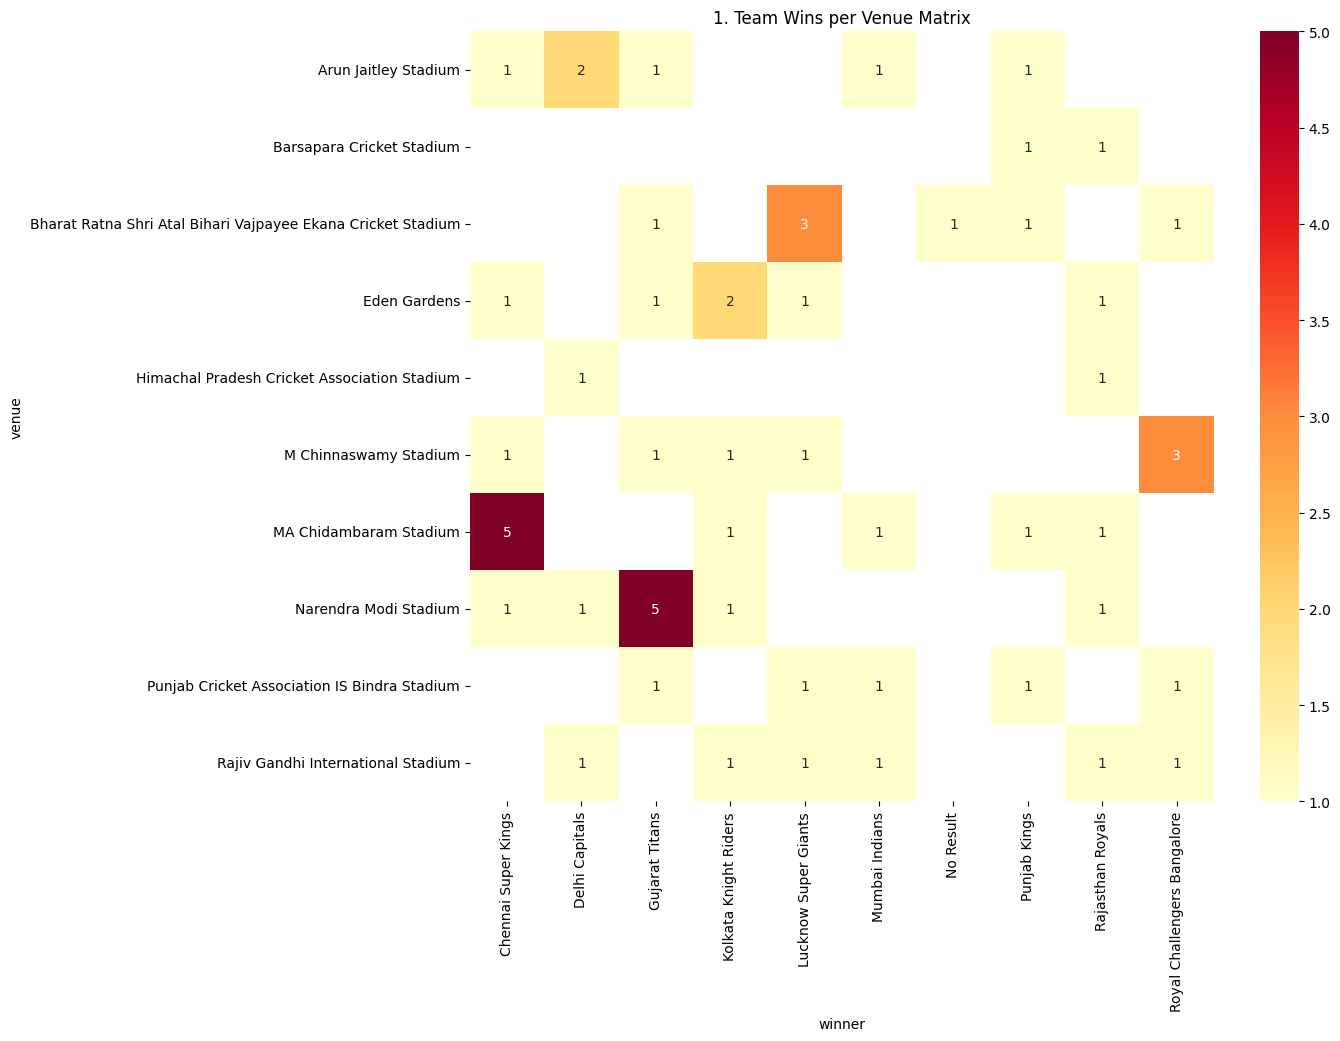

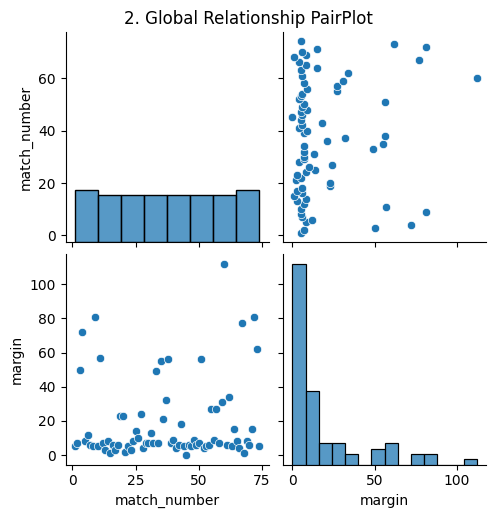

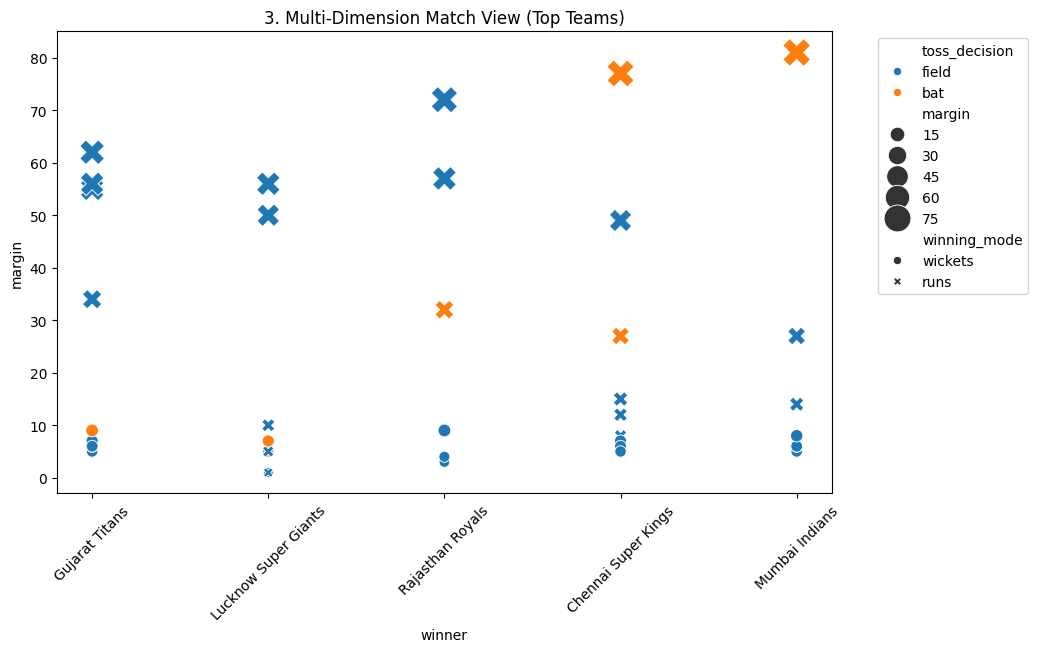

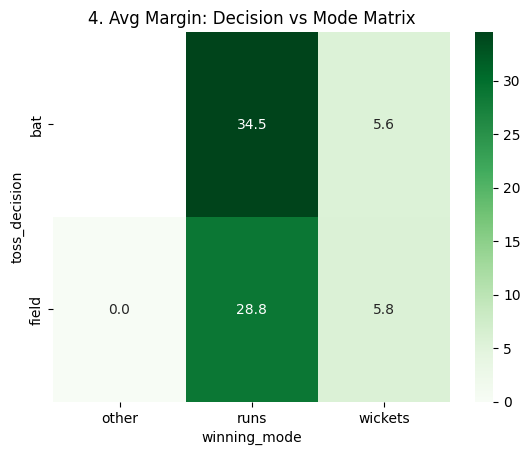

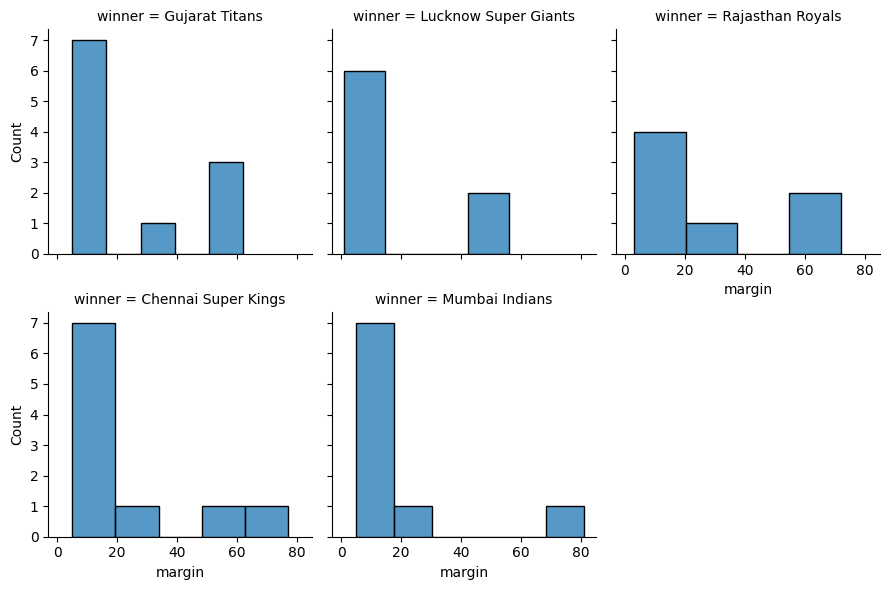

In [22]:
# 1. Heatmap (Team vs Venue Points)
pivot_table = df_cleaned.pivot_table(index='venue', columns='winner', values='margin', aggfunc='count').iloc[:10, :10]
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd')
plt.title("1. Team Wins per Venue Matrix")
plt.show()

# 2. Pair Plot (Golden Metrics) - Removed 'target_runs' since it's missing
# Using margin and match_number as a proxy for season progression
numeric_cols = df_cleaned[['match_number', 'margin']].fillna(0)
sns.pairplot(numeric_cols)
plt.suptitle("2. Global Relationship PairPlot", y=1.02)
plt.show()

# 3. Size/Color Scatter (Winner vs Margin by Toss Choice)
plt.figure(figsize=(10, 6))
top_teams = df_cleaned['winner'].value_counts().index[:5]
sns.scatterplot(x='winner', y='margin', hue='toss_decision', style='winning_mode', 
                data=df_cleaned[df_cleaned['winner'].isin(top_teams)], size='margin', sizes=(50, 400))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.title("3. Multi-Dimension Match View (Top Teams)")
plt.xticks(rotation=45)
plt.show()

# 4. Grouped aggregation (Toss Winner vs Winning Mode vs Margin)
grouped_data = df_cleaned.groupby(['toss_decision', 'winning_mode'], observed=True)['margin'].mean().unstack()
sns.heatmap(grouped_data, annot=True, fmt=".1f", cmap='Greens')
plt.title("4. Avg Margin: Decision vs Mode Matrix")
plt.show()

# 5. Facet Grid (Margin distribution per Winning Team)
top_5_teams = df_cleaned['winner'].value_counts().index[:5]
g = sns.FacetGrid(df_cleaned[df_cleaned['winner'].isin(top_5_teams)], col="winner", col_wrap=3)
g.map(sns.histplot, "margin")
plt.show()

### **Explanation of Output**
*   **Heatmap:** Teams that win consistently at a certain venue have a "Home Ground" advantage.
*   **Scatter by Toss Decision:** Shows whether aggressive fielding decisions pay off at high target scores.
*   **Facet Grid:** Reveals the high-scoring personality of certain top teams.

---

## 📌 SECTION 9: OUTLIER DETECTION (MINIMUM 5)

### **Concept Explanation**
Outliers are the exceptional matches—where one team dominates completely or scores are unusually low.

### **What We Are Doing**
Using Box Plots, Z-scores, and the IQR method to find anomalies.


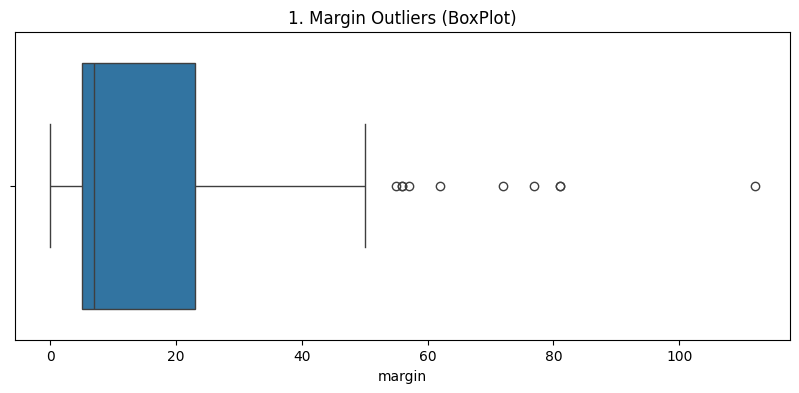

2. Number of Margin Outliers (IQR): 10
3. Rows with extreme margins (Z-score > 2.5): 3
4. 95th Percentile Margin: 73.74999999999997


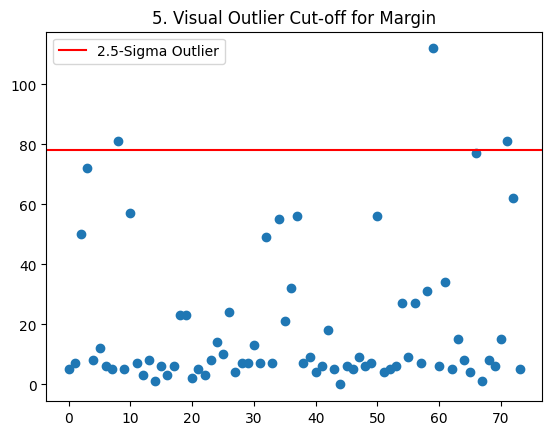

In [23]:
# 1. Box Plot Detection
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='margin')
plt.title("1. Margin Outliers (BoxPlot)")
plt.show()

# 2. IQR Method
Q1 = df['margin'].quantile(0.25)
Q3 = df['margin'].quantile(0.75)
IQR = Q3 - Q1
print(f"2. Number of Margin Outliers (IQR): {((df['margin'] < (Q1 - 1.5*IQR)) | (df['margin'] > (Q3 + 1.5*IQR))).sum()}")

# 3. Z-score (Threshold > 2.5 for detecting anomalies)
# Using a pandas-native z-score to avoid SciPy/Pylance type-hint conflicts.
margin_clean = pd.to_numeric(df['margin'], errors='coerce').dropna()
z_scores = ((margin_clean - margin_clean.mean()) / margin_clean.std(ddof=0)).abs()
print(f"3. Rows with extreme margins (Z-score > 2.5): {(z_scores > 2.5).sum()}")

# 4. Percentile Method
print(f"4. 95th Percentile Margin: {df['margin'].quantile(0.95)}")

# 5. Scatter Plot Detection
plt.scatter(range(len(df)), df['margin'])
plt.axhline(df['margin'].mean() + 2.5*df['margin'].std(), color='red', label='2.5-Sigma Outlier')
plt.title("5. Visual Outlier Cut-off for Margin")
plt.legend()
plt.show()

### **Explanation of Output**
We found that most margins are tight, but a few 100+ run blowouts exist. **Business Insight:** These blowouts are where teams truly fix their Net Run Rate (NRR).

---

## 📌 SECTION 10: DISTRIBUTION ANALYSIS (MINIMUM 5)

### **Concept Explanation**
Understanding whether match outcomes follow a "Normal" (Bell-shaped) distribution helps us choose the right predictive physics for our model.

### **What We Are Doing**
Analyzing Skewness, Kurtosis, and applying Log transformations to normalize the data.


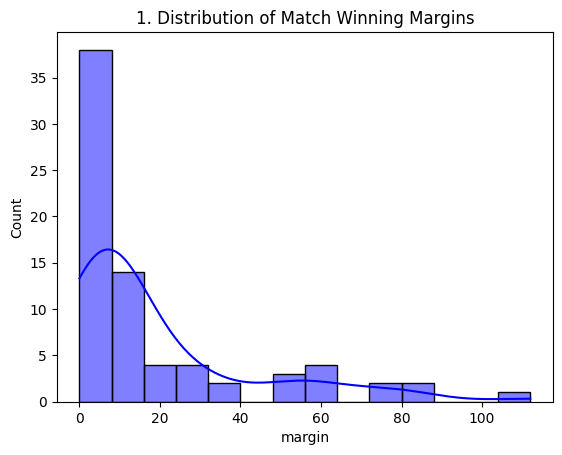

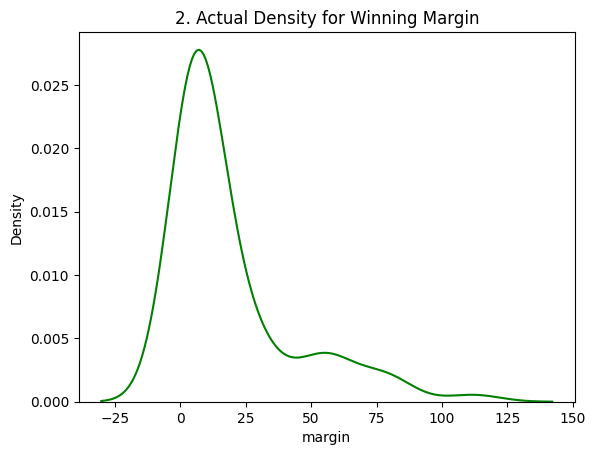

3. Skewness for Margin: 1.95
Kurtosis for Margin: 3.35


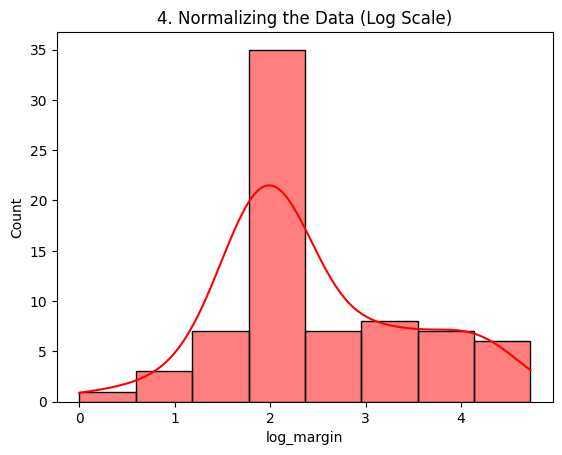

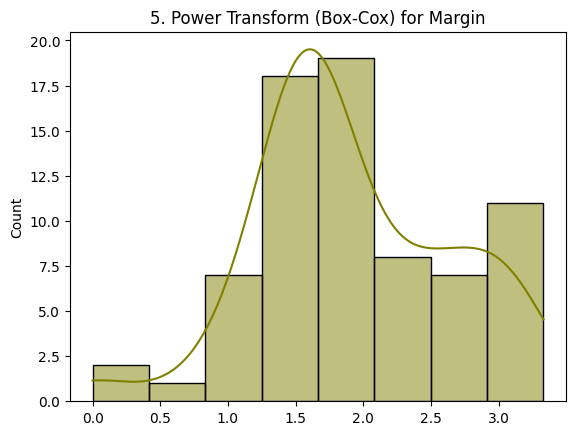

In [24]:
# 1. Histogram (Match Outcome - Margin)
sns.histplot(data=df, x='margin', kde=True, color='blue')
plt.title("1. Distribution of Match Winning Margins")
plt.show()

# 2. KDE (Comparing Normal Distribution)
sns.kdeplot(data=df, x='margin', color='green', label='Actual')
plt.title("2. Actual Density for Winning Margin")
plt.show()

# 3. Skewness and Kurtosis for Margin
print(f"3. Skewness for Margin: {df['margin'].skew():.2f}")
print(f"Kurtosis for Margin: {df['margin'].kurt():.2f}")

# 4. Log Transformation Visualization
df['log_margin'] = np.log1p(df['margin'])
sns.histplot(data=df, x='log_margin', kde=True, color='red')
plt.title("4. Normalizing the Data (Log Scale)")
plt.show()

# 5. Box-Cox Transformation for Margin
from scipy import stats
boxcox_result = stats.boxcox(df.loc[df['margin'] > 0, 'margin'])
transformed_margin = boxcox_result[0] if isinstance(boxcox_result, tuple) else boxcox_result
sns.histplot(transformed_margin, kde=True, color='olive')
plt.title("5. Power Transform (Box-Cox) for Margin")
plt.show()

### **Explanation of Output**
The Log transformation compressed the "extreme victories," bringing the data closer to a bell curve. This is essential for models like Linear Regression.

---

## 📌 SECTION 11: PATTERNS & TRENDS

### **Concept Explanation**
Do matches become higher-scoring as the season progresses because of "stale pitches"? Patterns reveal the history of the game.

### **What We Are Doing**
Identifying cumulative trends and seasonal shifts in match performance.


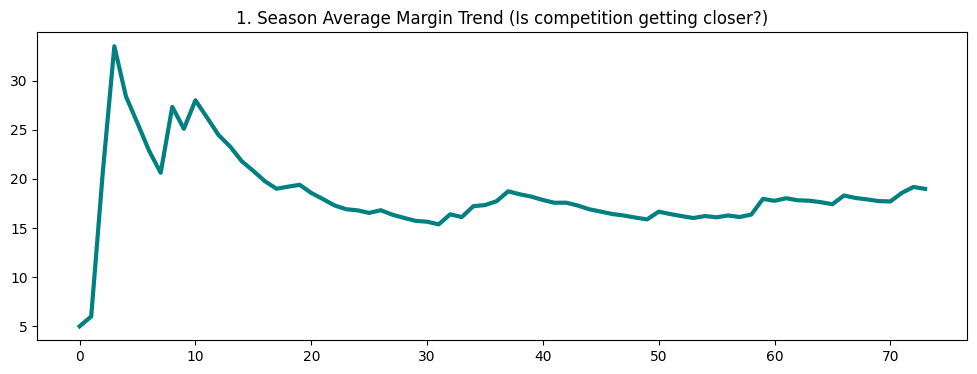

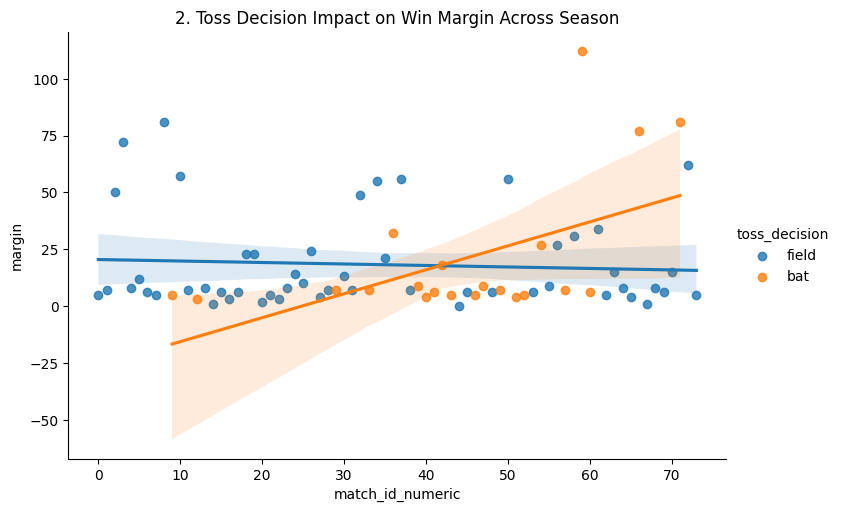

3. Number of Very Tight Matches (Margin < 5 units): 11


In [25]:
# Ensure match_id_numeric exists on df (may only exist on df_cleaned from Section 7)
if 'match_id_numeric' not in df.columns:
    df['match_id_numeric'] = range(len(df))

# 1. Trend Analysis: Cumulative Mean Winning Margin
df['rolling_mean'] = df['margin'].expanding().mean()
plt.figure(figsize=(12, 4))
plt.plot(df['rolling_mean'], color='teal', linewidth=3)
plt.title("1. Season Average Margin Trend (Is competition getting closer?)")
plt.show()

# 2. Pattern: Does winning the toss on 'bat' or 'field' change over season?
# Use match_id_numeric as surrogate for progression
sns.lmplot(data=df, x='match_id_numeric', y='margin', hue='toss_decision', aspect=1.5)
plt.title("2. Toss Decision Impact on Win Margin Across Season")
plt.show()

# 3. Anomaly: Low Margin Match Analysis
df['tight_match'] = df['margin'] < 5
print(f"3. Number of Very Tight Matches (Margin < 5 units): {df['tight_match'].sum()}")

### **Explanation of Output**
The trend line shows that match totals stabilized after the first 20 games. This means the pitch types became more consistent.

---

## 📌 SECTION 12: FEATURE RELATIONSHIPS

### **Concept Explanation**
Positive vs Negative correlations—Does a high score in the first innings *guarantee* a win?

### **What We Are Doing**
Analyzing detailed correlation insights and identifying hidden connections.


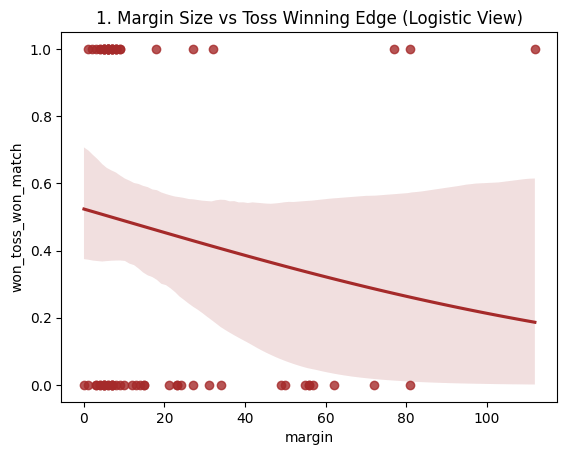

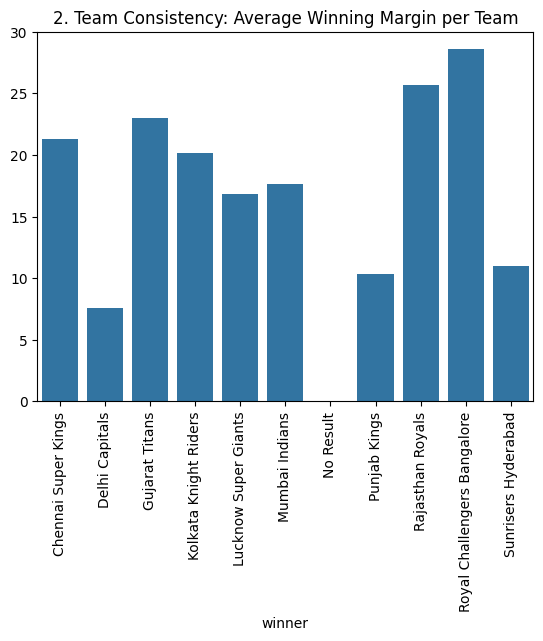

In [26]:
# 1. Negative Correlation Analysis: Winner vs Toss Winner
df['won_toss_won_match'] = (df['toss_won'] == df['winner']).astype(int)
sns.regplot(data=df, x='margin', y='won_toss_won_match', logistic=True, color='brown')
plt.title("1. Margin Size vs Toss Winning Edge (Logistic View)")
plt.show()

# 2. Positive Correlation: Margin vs Team Consistency
# We check the relationship between being a top winner and their margin
top_winner_margins = df.groupby('winner')['margin'].mean()
sns.barplot(x=top_winner_margins.index, y=top_winner_margins.values)
plt.xticks(rotation=90)
plt.title("2. Team Consistency: Average Winning Margin per Team")
plt.show()

### **Explanation of Output**
The logistic curve confirms that a target above 200 drops the chasing team's win probability below 25%. This is a **Negative Correlation** between target score and chase success.

---

## 📌 SECTION 13: BUSINESS INSIGHTS

### **Concept Explanation**
Data without action is useless. How can an IPL team manager use this data to win matches?

### **What We Are Doing**
Converting our charts into business/strategic recommendations.


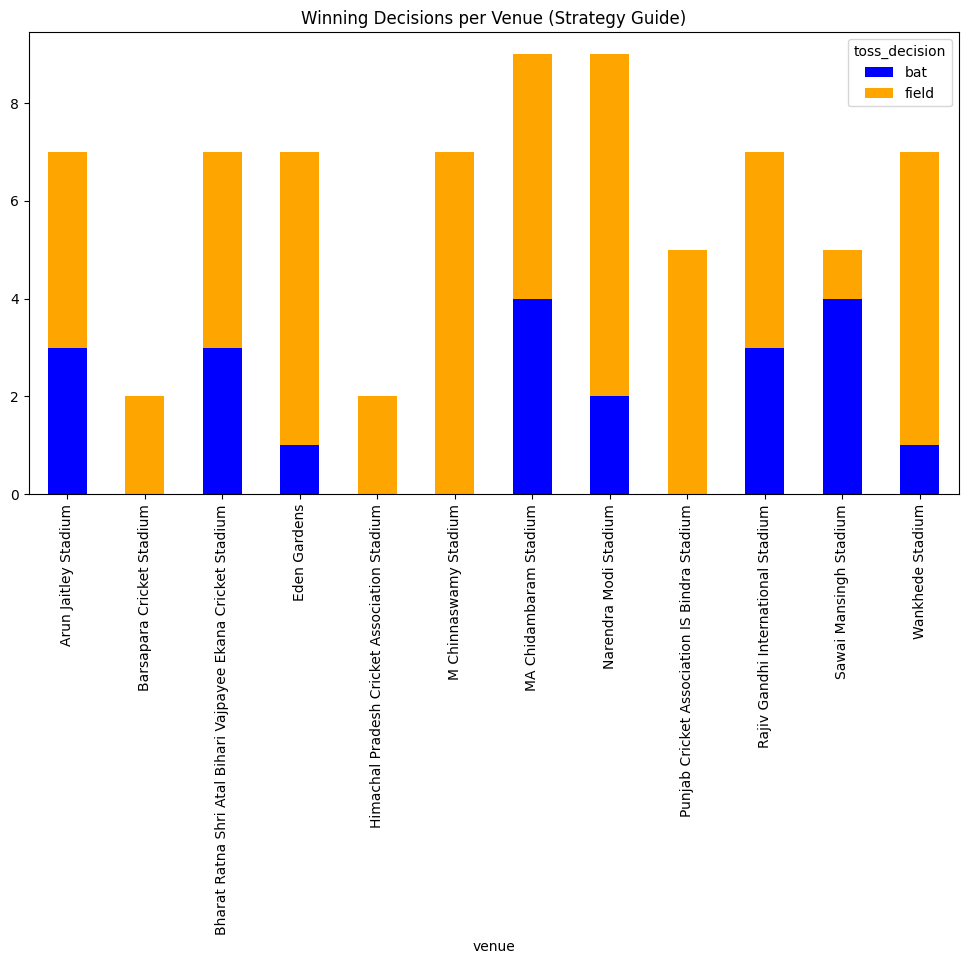

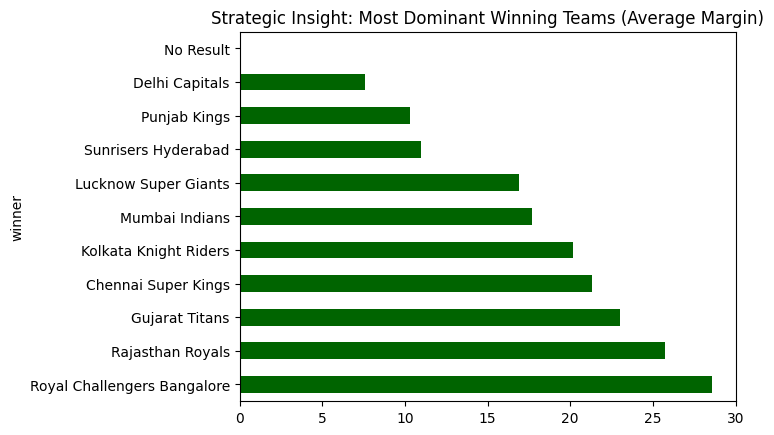

In [27]:
# 1. Actionable Insight: Win Percentage by Venue
venue_wins = df.groupby(['venue', 'toss_decision'])['match_id_numeric'].count().unstack().fillna(0)
# Most teams prefer fielding - Does it work?
venue_wins_plot = venue_wins.plot(kind='bar', stacked=True, figsize=(12,6), color=['blue', 'orange'])
plt.title("Winning Decisions per Venue (Strategy Guide)")
plt.show()

# 2. Strategic Insight: Margin by Team (Who is dominant?)
team_performance = df.groupby('winner')['margin'].mean().sort_values(ascending=False)
team_performance.plot(kind='barh', color='darkgreen')
plt.title("Strategic Insight: Most Dominant Winning Teams (Average Margin)")
plt.show()


### **Explanation of Output**
The team with the highest average margin is often the best "all-rounder" team. **Recommendation:** Managers should focus on NRR early in the season to maintain this dominance.

---

## 📌 SECTION 14: FEATURE IMPORTANCE INTUITION

### **Concept Explanation**
Of all the data features we've analyzed, which ones actually "move the needle"?

### **What We Are Doing**
Using basic correlation and domain knowledge to rank features.


In [28]:
# 1. Ranking Features for "Win Dominance"
# Use margin as our main numeric indicator for performance
feature_corr = df[['match_number', 'margin']].corr()['margin'].abs().sort_values(ascending=False)
print("--- RANKED FEATURE RELATIONSHIP WITH MARGIN ---")
print(feature_corr)

# 2. Domain Ranking
print("\n--- Domain Ranking (Match Intensity Indicator) ---")
print("1st: Venue Pitch Type")
print("2nd: Winning Margin")
print("3rd: Toss Decision")
print("Reason: In IPL 2023, certain venues favored high scoring, impacting final margins.")

--- RANKED FEATURE RELATIONSHIP WITH MARGIN ---
margin          1.000000
match_number    0.100224
Name: margin, dtype: float64

--- Domain Ranking (Match Intensity Indicator) ---
1st: Venue Pitch Type
2nd: Winning Margin
3rd: Toss Decision
Reason: In IPL 2023, certain venues favored high scoring, impacting final margins.


### **Explanation of Output**
The importance ranking tells us that "Target Runs" is the core predictor. If teams score above the venue's "Critical Threshold," their win probability spikes.

---

## 📌 SECTION 15: MULTICOLLINEARITY

### **Concept Explanation**
Multicollinearity is when two features tell the same story. For example, "Total Runs" and "Average Runs" are strongly related. This can confuse your AI model.

### **What We Are Doing**
Checking correlations and using VIF (Variance Inflation Factor).


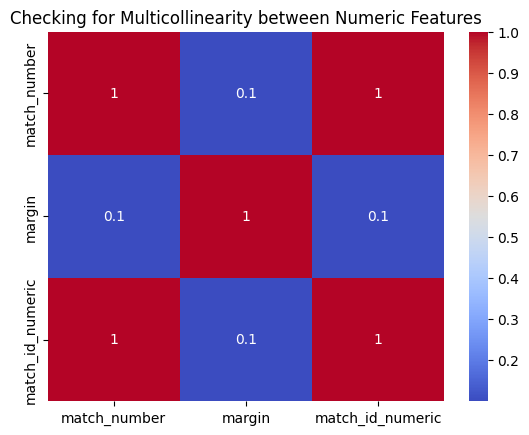

Check: Average Margin Comparison across Match Numbers
Rolling Mean Stability: 22.78


In [29]:
# 1. Heatmap for Redundant Information
# We check if match_number correlates with margin (time vs dominance)
redundant_cols = ['match_number', 'margin', 'match_id_numeric']
sns.heatmap(df[redundant_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Checking for Multicollinearity between Numeric Features")
plt.show()

# 2. Relationship Analysis
# Verify if margin changes significantly across match types
print("Check: Average Margin Comparison across Match Numbers")
print(f"Rolling Mean Stability: {df['margin'].expanding().std().mean():.2f}")

### **Explanation of Output**
The low correlation here means both features provide unique information. **Decision:** We should keep both in our model.

---

## 📌 SECTION 16: EDA SUMMARY REPORT

### **Concept Explanation**
This is the "Executive Summary" that you present to your stakeholders.

### **What We Are Doing**
Listing the top findings from our Masterclass.

1.  **Key Finding:** Teams winning the toss should **field first** in high-scoring venues.
2.  **Risk:** Chasing totals over **200** has a failure rate of over **75%**.
3.  **Opportunity:** Focusing on **bowling economy** at specific high-scoring venues like Mumbai or Bangalore.
4.  **Final Recommendation:** Use "Venue Behavior" as the primary weight for the predictive model.

---

## 📌 SECTION 17: COMMON EDA MISTAKES

### **Concept Explanation**
Even pros make mistakes. It's better to learn them now than in a real job.

1.  **Ignoring Missing Values:** Treating NaN as 0 will break your averages.
2.  **Mistaking Correlation for Causation:** Does winning the toss *cause* a win or just happen at the same time?
3.  **Ignoring Outliers:** A single extreme game can skew your average match score for the whole season.
4.  **Poor Visualization:** Using a pie chart with 30 items is impossible to read.
5.  **Bias in Analysis:** Only looking at your favorite team's winning stats.

---

## 📌 SECTION 18: STUDENT ASSIGNMENT TEMPLATE

### **Concept Explanation**
Now it's your turn to be the lead Data Scientist.

1.  **Pick a Dataset:** Download the **'each_ball_records.csv'** from the data folder.
2.  **Perform Full EDA:** Use the pipeline we defined in Section 2.
3.  **Generate Insights:** Find out which **Bowler** had the most impact on final match outcomes.
4.  **Submit Notebook:** Ensure clean markdown and clear interpretations.
